In [12]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                    compute_cell_metrics, neighbor_qa, flag_outlier_pairs,
                    group_dumps_by_cell, compute_cell_gains,
                    apply_tsys_calibration, compute_R_for_dumps)
from plotters import plot_spectra_grid, plot_survey_mollweide
from ugradiolab import plotting
from ugradiolab.plotting import SS_FINE

from pathlib import Path
from collections import defaultdict
from matplotlib.backends.backend_pdf import PdfPages
import datetime as dt
import json
import numpy as np
import pandas as pd
import astropy.coordinates as ac
import astropy.units as u_ast
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

F1_MHZ = 1419.86
F2_MHZ = 1421.14

T_CAL_00 = 79.0  # K, pol 0
T_CAL_11 = 58.0  # K, pol 1

HPBW_DEG = 3.4

# --- RFI channel flagger (utils.flag_rfi_channels) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter (utils.flag_outlier_dumps) ---
SHAPE_DEV_THRESH = 0.10
SHAPE_FRAC_THRESH = 0.20
SHAPE_MIN_GROUP_SIZE = 3

# --- Frequency switching (Section 4) ---
EDGE_TRIM_MHZ = 0.256

# --- Calibration (utils.compute_cell_gains / apply_tsys_calibration) ---
CAL_SPECTRUM_KEY = 'corr11'
CAL_GAIN_KEY = 'gain_11'

# --- Cross-session pair filter (utils.flag_outlier_pairs) ---
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.10
MIN_VIABLE_PAIRS = 3
PAIR_SPECTRUM_KEY = 'R_lsr'

# --- Per-cell metrics (utils.compute_cell_metrics) ---
METRIC_MIN_VALID_CH = 8
METRIC_NOISE_V_MAX_KMS = -100.0
METRIC_SIGNAL_V_LO_KMS = -80.0
METRIC_SIGNAL_V_HI_KMS = 60.0
METRIC_SMOOTH_KERNEL = 5
METRIC_PEAK_MIN_SEP_KMS = 4.0
METRIC_PEAK_PROM_NSIGMA = 2.5
METRIC_MIN_NOISE_CH = 5

# --- Neighbor QA (utils.neighbor_qa) ---
NEIGHBOR_MAX_SEP_DEG = 4.5
MIN_NEIGHBORS = 5
W_Z_THRESH = 3.5
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 5.0
PEAK_V_Z_THRESH = 4.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0
BIMODAL_MIN_RATIO = 0.68

# --- Paths / display ---
DATA_DIR = Path('../../../../data/lab04/main')
REOBSERVE_PATH = Path('../../scripts/main/reobserve.json')
MOLL_CENTER_L = 120.0

%matplotlib inline

## 1. Load raw dumps

In [13]:
records = []
for session_dir in sorted(DATA_DIR.glob('session_*')):
    for cell_dir in sorted(session_dir.glob('obs_*')) + sorted(session_dir.glob('cal_*')):
        for p in sorted(cell_dir.glob('*.npz')):
            with np.load(p, allow_pickle=True) as f:
                records.append({
                    'path': p,
                    'session': session_dir.name,
                    'target': str(f['target_name']),
                    'corr00': f['corr00'].astype(float),
                    'corr11': f['corr11'].astype(float),
                    'lo_mhz': float(f['lo_freq_mhz']),
                    'noise_on': bool(f['noise_on']),
                    'time': float(f['time']),
                    'alt': float(f['alt_deg']),
                    'az': float(f['az_deg']),
                    'ra': float(f['ra_deg']),
                    'dec': float(f['dec_deg']),
                })

N = len(records)

# Galactic coordinates from RA/Dec
for r in records:
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg, 2)
    r['gb'] = round(c.galactic.b.deg)

sessions = sorted(set(r['session'] for r in records))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

# Integration time per dump (seconds): NBLOCKS * NSAMPLES / fs
INT_TIME_S = 1025 * 32768 / SAMPLE_RATE_HZ  # ~10.5 s


def _utc(ts):
    return dt.datetime.fromtimestamp(ts, dt.UTC).strftime('%Y-%m-%d %H:%M')


session_data = []
for s in sessions:
    s_records = [r for r in records if r['session'] == s]
    n_dumps = len(s_records)
    if n_dumps == 0:
        continue
    n_cells = len(set((r['gl'], r['gb']) for r in s_records if not r['noise_on']))
    times = [r['time'] for r in s_records]
    t0, t1 = min(times), max(times)
    wall_s = t1 - t0
    duty_pct = (INT_TIME_S * n_dumps / wall_s) * 100 if wall_s > 0 else float('nan')
    session_data.append({
        'Session': s,
        'UTC Start': _utc(t0),
        'UTC End':   _utc(t1),
        'Wall (min)': round(wall_s / 60, 1),
        'Obs. Cells': n_cells,
        'Dumps': n_dumps,
        'Duty %': round(duty_pct, 1),
    })
display(pd.DataFrame(session_data))

print(f'Total: {N} dumps ({n_sci} science, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')

,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,session_001,2026-04-25 09:30,2026-04-25 10:43,72.8,31,249,59.8
1,session_002,2026-04-25 10:51,2026-04-25 10:53,2.2,1,8,63.8
2,session_003,2026-04-25 11:03,2026-04-25 18:14,430.6,140,1067,43.3
3,session_004,2026-04-25 18:19,2026-04-25 18:28,8.9,4,25,49.3
4,session_005,2026-04-25 18:31,2026-04-25 18:34,3.2,2,10,54.7
5,session_006,2026-04-25 18:39,2026-04-25 19:17,37.9,23,179,82.6
6,session_007,2026-04-25 19:20,2026-04-26 03:56,516.1,260,2080,70.5
7,session_008,2026-04-26 04:12,2026-04-26 04:15,3.1,2,16,89.5
8,session_009,2026-04-26 04:26,2026-04-26 04:31,5.1,3,24,82.6
9,session_010,2026-04-26 04:36,2026-04-26 04:37,1.3,1,8,107.0


Total: 7381 dumps (5567 science, 1814 cal), 18 sessions, LO: [1419.86, 1421.14]


## 2. fftshift + RFI flagging + outlier dump filter

In [14]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0 / SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])
    r['stokes_I'] = r['corr11']  # pol 1 only -- pol 0 has bad noise-diode coupling at 3.2 MHz

n_flagged = sum(
    flag_rfi_channels(
        r['stokes_I'],
        window=RFI_WINDOW,
        sigma_thresh=RFI_SIGMA,
        degree=RFI_CHEB_DEGREE,
        sample_frac=RFI_SAMPLE_FRAC,
        extrema_order=RFI_EXTREMA_ORDER,
    )
    for r in records
)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz, '
      f'dnu = {df_khz:.2f} kHz')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')
print('NOTE: using pol 1 (corr11) only')

Baseband: [-1.600, 1.597] MHz, dnu = 3.12 kHz
RFI flagged: 28400 samples across 7381 dumps
NOTE: using pol 1 (corr11) only


In [15]:
outlier_records = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
N = len(records)

print(f'Outlier dump filter (spectral shape): removed {len(outlier_records)} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {N} dumps')

Outlier dump filter (spectral shape): removed 0 dumps
  (flag if >20% of channels deviate >10% from group median)
Remaining: 7381 dumps


## 4. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.

In [16]:
lo1, lo2 = F1_MHZ, F2_MHZ
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)
dv_kms = np.abs(np.median(np.diff(v_overlap)))

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')

# Frequency-switched R per (session, cell)
all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

cell_results = {}
for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]
    for dr in sessions:
        dr_dumps = [r for r in sci_dumps if r['session'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.660 km/s per channel


/home/ikaros/projects/ay-121/labs/04/notebooks/main/../utils/freqswitch.py:107: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_cat, axis=0)


## 5. Per-cell gain calibration

Each cell has its own cal-on/cal-off pair. Compute gain per cell,
then T_sys = P_off / gain. Convert R -> T_B = R * T_sys.

In [17]:
dc_mask = np.ones(NFFT, dtype=bool)
dc_mask[DC_BIN] = False

# Per-cell gain from pol 1 only (pol 0 has unreliable noise-diode coupling).
cal_dumps, obs_dumps_by_cell = group_dumps_by_cell(records)
cell_gains = compute_cell_gains(
    cal_dumps, obs_dumps_by_cell, dc_mask, T_CAL_11,
    spectrum_key=CAL_SPECTRUM_KEY, gain_key=CAL_GAIN_KEY,
)
print(f'Gain computed for {len(cell_gains)} (session, cell) entries')

cell_results_TB = apply_tsys_calibration(
    cell_results, cell_gains, obs_dumps_by_cell, dc_mask,
    spectrum_key=CAL_SPECTRUM_KEY, gain_key=CAL_GAIN_KEY,
)
print(f'Calibrated {len(cell_results_TB)} (session, cell) entries')

# Gain summary
gain_rows = []
for (dr, gl, gb), v in sorted(cell_results_TB.items()):
    gain_rows.append({
        'session': dr, 'gl': gl, 'gb': gb,
        CAL_GAIN_KEY: v[CAL_GAIN_KEY],
        'T_sys': v['T_sys'],
    })
gain_df = pd.DataFrame(gain_rows)
if len(gain_df):
    print(f'\nGain stats (pol 1 only):')
    print(f'  {CAL_GAIN_KEY}: {gain_df[CAL_GAIN_KEY].median():.2f} (median), '
          f'range [{gain_df[CAL_GAIN_KEY].min():.2f}, {gain_df[CAL_GAIN_KEY].max():.2f}]')
    print(f'  T_sys:   {gain_df["T_sys"].median():.0f} K (median), '
          f'range [{gain_df["T_sys"].min():.0f}, {gain_df["T_sys"].max():.0f}] K')

/home/ikaros/projects/ay-121/labs/04/notebooks/main/../utils/calibration.py:50: RuntimeWarning: Mean of empty slice
  P_on = np.nanmean([c[spectrum_key] for c in cals], axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/main/../utils/calibration.py:51: RuntimeWarning: Mean of empty slice
  P_off = np.nanmean([o[spectrum_key] for o in obs], axis=0)


Gain computed for 933 (session, cell) entries
Calibrated 926 (session, cell) entries

Gain stats (pol 1 only):
  gain_11: 6.06 (median), range [4.01, 8.70]
  T_sys:   97 K (median), range [75, 138] K


## 6. LSR correction, cross-session pair filter, and combine

Build per-pair R for each cell across all sessions, LSR-shift each pair onto a
common grid, reject outlier pairs via population MAD (cross-session), then
average the surviving pairs. Cells with fewer than `MIN_VIABLE_PAIRS` after
filtering are queued for reobservation.

In [18]:
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on']:
        continue
    cell_dr_groups[(r['session'], r['gl'], r['gb'])].append(r)

session_cell_vcorr = {}
for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    session_cell_vcorr[key] = vlsr_correction(r0['ra'], r0['dec'], mean_t)

sci_vcorr = list(session_cell_vcorr.values())
mean_vcorr = np.mean(sci_vcorr) if sci_vcorr else 0.0
v_lsr_overlap = v_overlap + mean_vcorr
v_lsr_inc = v_lsr_overlap[::-1]

if sci_vcorr:
    print(f'v_corr range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
          f'(mean {mean_vcorr:.2f})')
    print(f'Velocity (LSR): [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')
else:
    print('No science dumps -- skipping LSR correction')

# Build per-pair R for each (gl, gb), LSR-shifted onto the common grid.
# Preserves pair-level data so we can run a cross-session outlier filter.
cell_pairs = defaultdict(list)  # (gl, gb) -> list of {'session', PAIR_SPECTRUM_KEY, 'pair_idx'}

for (dr, gl, gb), dumps in obs_dumps_by_cell.items():
    d1 = [r for r in dumps if r['lo_mhz'] == lo1]
    d2 = [r for r in dumps if r['lo_mhz'] == lo2]
    n_p = min(len(d1), len(d2))
    if n_p == 0:
        continue

    I1 = np.array([r['stokes_I'] for r in d1[:n_p]])
    I2 = np.array([r['stokes_I'] for r in d2[:n_p]])
    R_pairs = (I1 - I2) / I2  # (n_p, NFFT)
    R_pairs_ov = R_pairs[:, overlap_mask]

    v_corr = session_cell_vcorr.get((dr, gl, gb), 0.0)
    v_shifted = v_overlap + v_corr

    for i in range(n_p):
        R_lsr = np.interp(v_lsr_inc, v_shifted[::-1],
                          R_pairs_ov[i][::-1],
                          left=np.nan, right=np.nan)[::-1]
        cell_pairs[(gl, gb)].append({
            'session': dr,
            PAIR_SPECTRUM_KEY: R_lsr,
            'pair_idx': i,
        })

# Cross-session per-pair outlier filter (population MAD).
n_pairs_total = sum(len(v) for v in cell_pairs.values())
viable_pairs_per_cell, flagged_pair_records = flag_outlier_pairs(
    cell_pairs,
    n_sigma=PAIR_NSIGMA,
    frac_thresh=PAIR_FRAC_THRESH,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Pair filter: flagged {len(flagged_pair_records)}/{n_pairs_total} pairs '
      f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')

# Aggregate viable pairs into cell_combined. Convert each pair R -> T_B using
# its source session's T_sys, then average across surviving pairs.
cell_combined = {}
cells_insufficient_pairs = []

for (gl, gb), pairs in viable_pairs_per_cell.items():
    TB_list = []
    R_list = []
    tsys_list = []
    for p in pairs:
        tb_key = (p['session'], gl, gb)
        if tb_key not in cell_results_TB:
            continue
        T_sys_s = cell_results_TB[tb_key]['T_sys']
        TB_list.append(p[PAIR_SPECTRUM_KEY] * T_sys_s)
        R_list.append(p[PAIR_SPECTRUM_KEY])
        tsys_list.append(T_sys_s)

    n_viable = len(TB_list)
    if n_viable == 0:
        cells_insufficient_pairs.append({'l': gl, 'b': int(gb), 'n_viable': 0})
        continue

    cell_combined[(gl, gb)] = {
        'T_B': np.nanmean(TB_list, axis=0),
        'R': np.nanmean(R_list, axis=0),
        'T_sys': float(np.mean(tsys_list)),
        'n_pairs': n_viable,
    }

    if n_viable < MIN_VIABLE_PAIRS:
        cells_insufficient_pairs.append({'l': gl, 'b': int(gb), 'n_viable': n_viable})

n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['T_B'])) >= 8)
print(f'Combined (LSR): {len(cell_combined)} cells ({n_valid} with >=8 valid channels)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')

Computing LSR corrections...
v_corr range: -42.95 to 43.23 km/s (mean 7.40)
Velocity (LSR): [-161, 136] km/s


/home/ikaros/projects/ay-121/labs/04/notebooks/main/../utils/qa.py:547: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/main/../utils/qa.py:548: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826


Pair filter: flagged 10/2770 pairs (NSIGMA=5.0, frac>10%)
Combined (LSR): 862 cells (862 with >=8 valid channels)
Cells with <3 viable pairs: 15


/tmp/ipykernel_126662/4031218288.py:91: RuntimeWarning: Mean of empty slice
  'T_B': np.nanmean(TB_list, axis=0),
/tmp/ipykernel_126662/4031218288.py:92: RuntimeWarning: Mean of empty slice
  'R': np.nanmean(R_list, axis=0),


# N. Neighbour-based QA

In [19]:
# Wrap cell_combined so keys match what compute_cell_metrics expects
cell_combined_qa = {
    k: {'R_overlap': v['R'], 'n_pairs': v['n_pairs']}
    for k, v in cell_combined.items()
}

cell_metrics = compute_cell_metrics(
    cell_combined_qa, v_lsr_overlap, dv_kms,
    min_valid_ch=METRIC_MIN_VALID_CH,
    noise_v_max_kms=METRIC_NOISE_V_MAX_KMS,
    signal_v_lo_kms=METRIC_SIGNAL_V_LO_KMS,
    signal_v_hi_kms=METRIC_SIGNAL_V_HI_KMS,
    smooth_kernel=METRIC_SMOOTH_KERNEL,
    peak_min_sep_kms=METRIC_PEAK_MIN_SEP_KMS,
    peak_prom_nsigma=METRIC_PEAK_PROM_NSIGMA,
    min_noise_ch=METRIC_MIN_NOISE_CH,
)
neighbor_cells = neighbor_qa(
    cell_metrics,
    dv_kms=dv_kms,
    hpbw_deg=HPBW_DEG,
    neighbor_max_sep_deg=NEIGHBOR_MAX_SEP_DEG,
    min_neighbors=MIN_NEIGHBORS,
    w_z_thresh=W_Z_THRESH,
    w_frac_thresh=W_FRAC_THRESH,
    w_scale_floor=W_SCALE_FLOOR,
    peak_v_z_thresh=PEAK_V_Z_THRESH,
    peak_v_abs_thresh=PEAK_V_ABS_THRESH,
    peak_v_min_sigma=PEAK_V_MIN_SIGMA,
    peak_v_scale_floor=PEAK_V_SCALE_FLOOR,
    bimodal_min_ratio=BIMODAL_MIN_RATIO,
)

neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
neighbor_w_flag_count = sum(1 for c in neighbor_cells if c['W_flag'])
neighbor_peak_flag_count = sum(1 for c in neighbor_cells if c['peak_v_flag'])

print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed')
print(f'  Flags: W={neighbor_w_flag_count}, peak_v={neighbor_peak_flag_count}, '
      f'any={len(neighbor_flagged)}')

if neighbor_flagged:
    print('  Most deviant cells:')

    def severity(cell):
        w_score = abs(cell['W_frac_resid']) if np.isfinite(cell['W_frac_resid']) else 0.0
        v_score = abs(cell['peak_v_z']) if np.isfinite(cell['peak_v_z']) else 0.0
        return max(w_score, v_score)

    for cell in sorted(neighbor_flagged, key=severity, reverse=True)[:12]:
        print(
            f"    l={cell['gl']:6.2f} b={cell['gb']:3d} "
            f"W={cell['W']:+.3f} (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
            f"v_peak={cell['peak_v']:+.1f} km/s "
            f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
            f"n={cell['neighbor_count']}"
        )

Neighbor QA: 862 cells analyzed
  Flags: W=2, peak_v=0, any=2
  Most deviant cells:
    l= 79.90 b=  4 W=+21.666 (frac=-0.31, z=-4.13) v_peak=+6.3 km/s (dv=+4.7, z=+1.57) n=18
    l=186.16 b= -4 W=+13.106 (frac=-0.30, z=-6.84) v_peak=+3.1 km/s (dv=-0.6, z=-0.19) n=10


In [20]:
# Cells to reobserve: union of neighbor-QA flags and insufficient-pair cells.
reobs_map = {}  # (l, b) -> {'l', 'b', 'reason'}

for c in neighbor_cells:
    if not (c['W_flag'] or c['peak_v_flag']):
        continue
    flags = []
    if c['W_flag']:
        flags.append('W')
    if c['peak_v_flag']:
        flags.append('peak_v')
    key = (c['gl'], int(c['gb']))
    reobs_map[key] = {'l': c['gl'], 'b': int(c['gb']),
                      'reason': '+'.join(flags)}

for c in cells_insufficient_pairs:
    key = (c['l'], int(c['b']))
    tag = f"insufficient_pairs(n={c['n_viable']})"
    if key in reobs_map:
        reobs_map[key]['reason'] += '+' + tag
    else:
        reobs_map[key] = {'l': c['l'], 'b': int(c['b']), 'reason': tag}

reobs = sorted(reobs_map.values(), key=lambda r: (r['b'], r['l']))

REOBSERVE_PATH.write_text(json.dumps(reobs, indent=2) + '\n')
print(f'Wrote {REOBSERVE_PATH} -- {len(reobs)} cells')
for r in reobs:
    print(f"  l={r['l']:7.2f} b={r['b']:+3d}  ({r['reason']})")

Wrote ../../scripts/main/reobserve.json -- 17 cells
  l= 186.16 b= -4  (W)
  l= 139.03 b= -3  (insufficient_pairs(n=1))
  l=  71.97 b= -2  (insufficient_pairs(n=2))
  l= 151.00 b= -1  (insufficient_pairs(n=0))
  l= 159.01 b= -1  (insufficient_pairs(n=1))
  l= 161.01 b= -1  (insufficient_pairs(n=0))
  l= 165.01 b= -1  (insufficient_pairs(n=0))
  l= 111.00 b= +1  (insufficient_pairs(n=1))
  l= 179.01 b= +1  (insufficient_pairs(n=1))
  l= 183.01 b= +1  (insufficient_pairs(n=0))
  l= 191.01 b= +1  (insufficient_pairs(n=2))
  l= 193.01 b= +1  (insufficient_pairs(n=0))
  l= 143.03 b= +3  (insufficient_pairs(n=2))
  l= 147.04 b= +3  (insufficient_pairs(n=2))
  l=  59.85 b= +4  (insufficient_pairs(n=2))
  l=  65.87 b= +4  (insufficient_pairs(n=2))
  l=  79.90 b= +4  (W)


In [21]:
# Cells the rest of the pipeline does not trust.
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
insufficient_set = {(c['l'], c['b']) for c in cells_insufficient_pairs}
excluded_cells = qa_flagged_set | insufficient_set

# Build per-(session, cell) R from the cross-session-filtered viable pairs.
# (Spectra are on the common LSR grid, not topocentric.)
viable_per_session_cell = defaultdict(list)
for (gl, gb), pairs in viable_pairs_per_cell.items():
    if (gl, gb) in excluded_cells:
        continue
    for p in pairs:
        viable_per_session_cell[(p['session'], gl, gb)].append(p['R_lsr'])


def _safe_nanmean_stack(rs):
    """nanmean over axis 0 without a warning when some columns are all-NaN."""
    stack = np.array(rs)
    col_has_data = np.any(np.isfinite(stack), axis=0)
    mean = np.full(stack.shape[1], np.nan)
    if col_has_data.any():
        mean[col_has_data] = np.nanmean(stack[:, col_has_data], axis=0)
    return mean


with PdfPages('spectra_per_session.pdf') as pdf:
    for dr in sessions:
        dr_spectra = {
            (l, b): _safe_nanmean_stack(rs)
            for (d, l, b), rs in viable_per_session_cell.items()
            if d == dr
        }
        if not dr_spectra:
            continue
        result = plot_spectra_grid(
            v_lsr_overlap, dr_spectra,
            ncols=5,
            color='C0',
            title=f'{dr} -- {len(dr_spectra)} pointings '
                  f'(post pair filter + QA, LSR frame)',
        )
        figs = result if isinstance(result, list) else [result]
        for f in figs:
            pdf.savefig(f)
            plt.close(f)

n_excluded = len(excluded_cells)
print(f'Saved spectra_per_session.pdf '
      f'(excluded {n_excluded} cells: {len(qa_flagged_set)} QA + '
      f'{len(insufficient_set)} insufficient-pairs)')

Saved spectra_per_session.pdf (excluded 17 cells: 2 QA + 15 insufficient-pairs)


## 7. Integrated intensity map W(l, b)

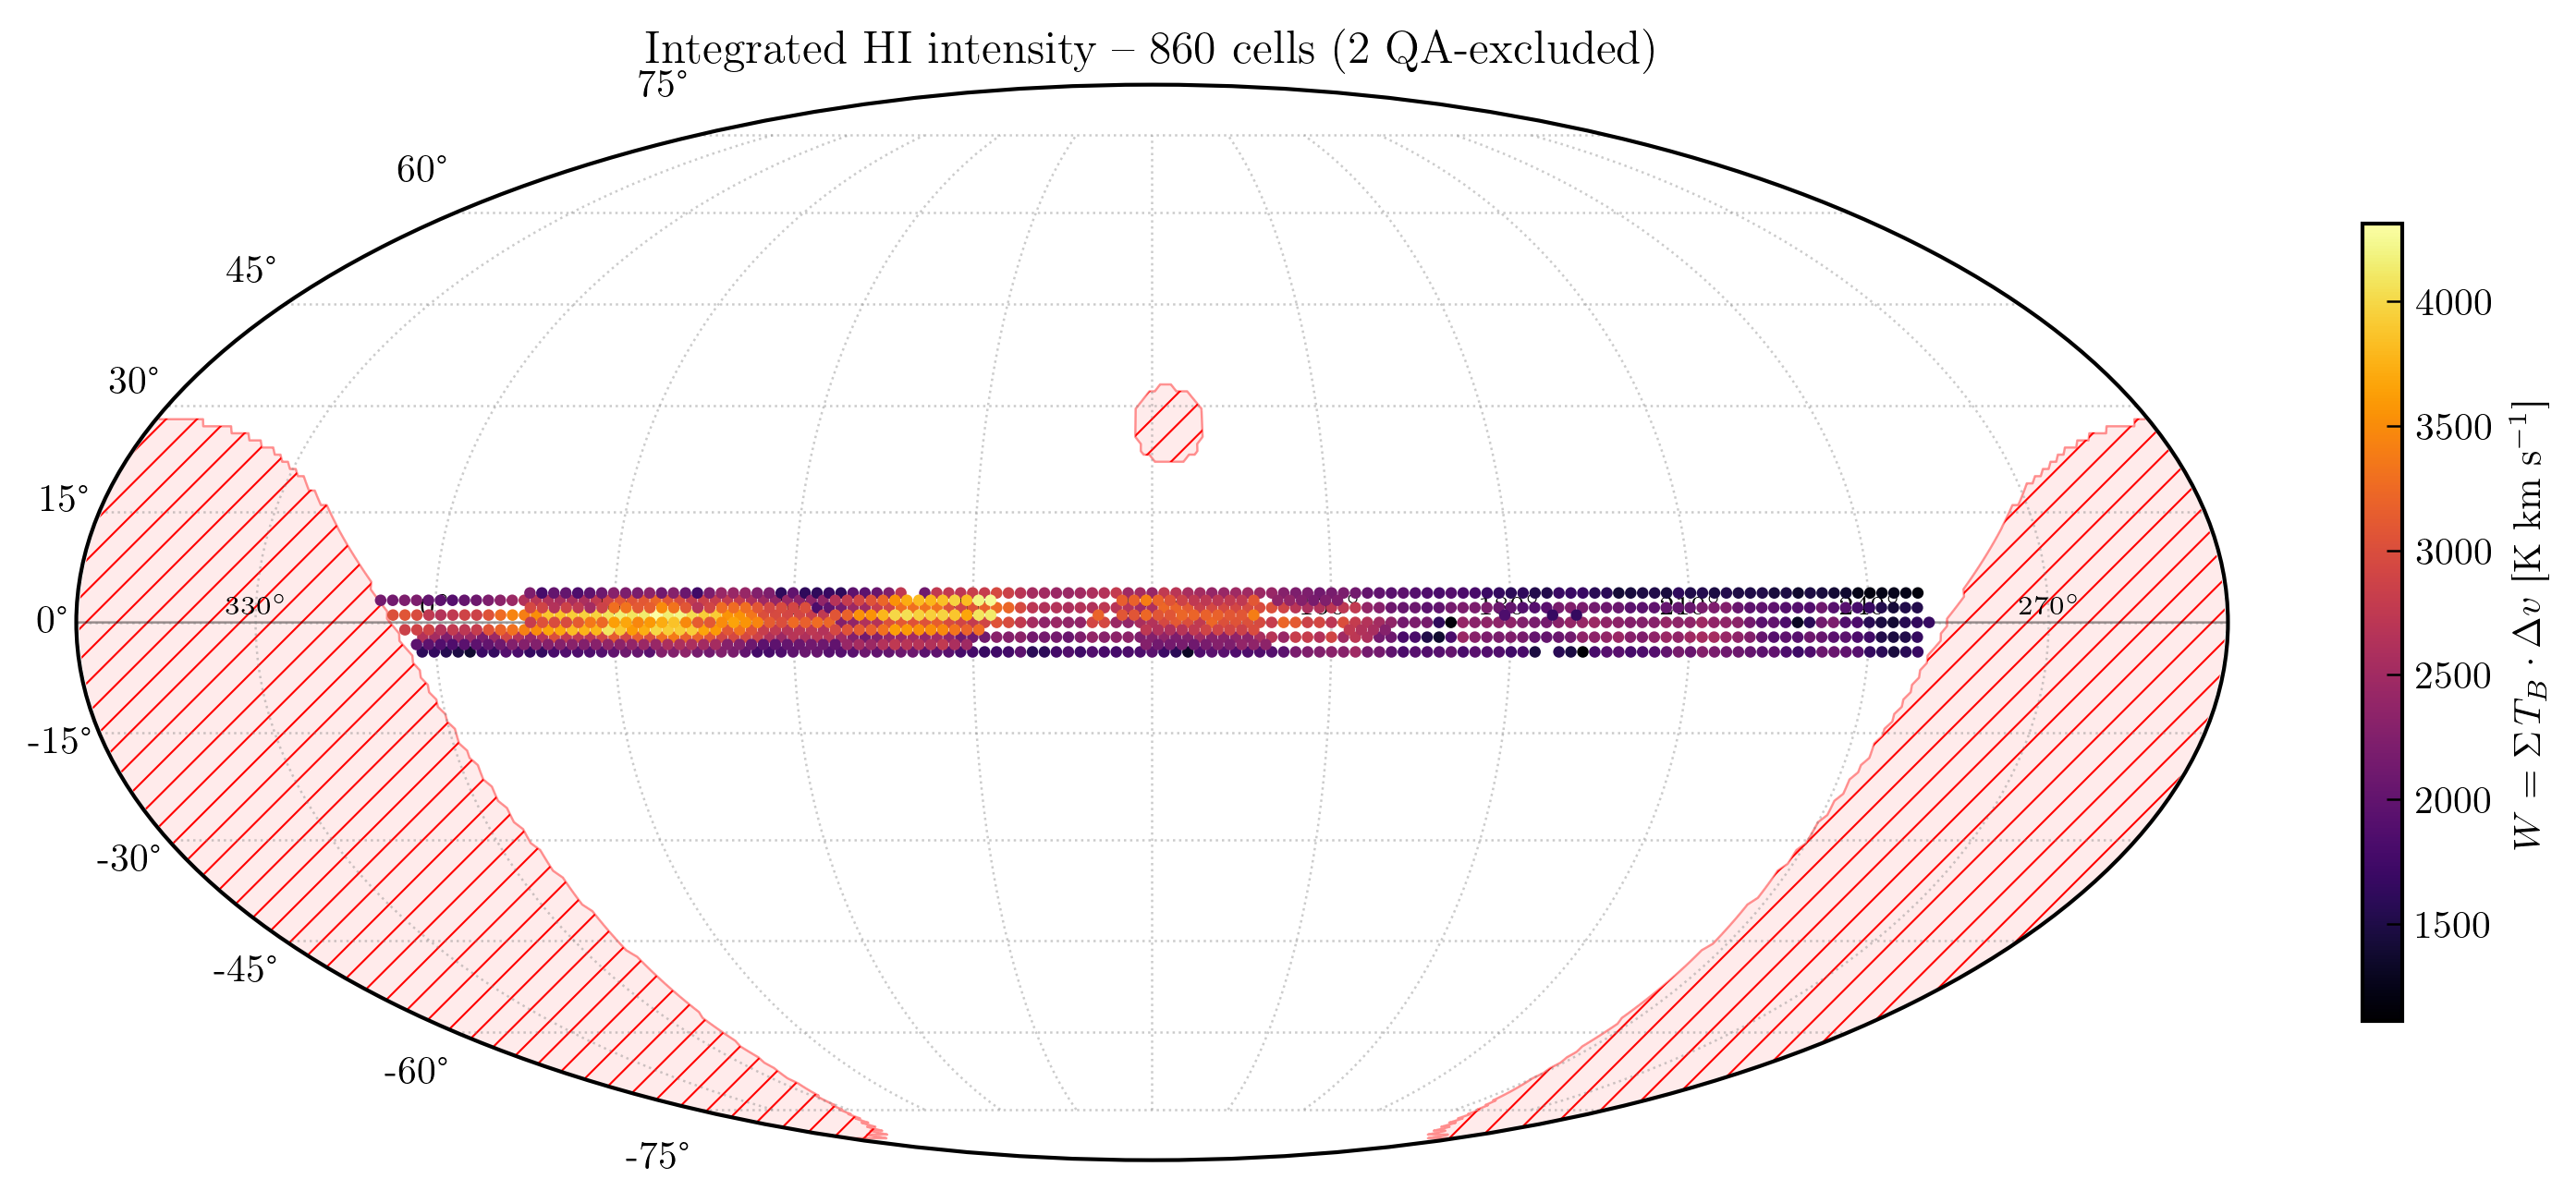

In [22]:
# QA-flagged cells to exclude
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}

# Build arrays from cell_combined, excluding QA-flagged cells
cell_keys_clean = [k for k in cell_combined if k not in qa_flagged_set]
gl_arr = np.array([k[0] for k in cell_keys_clean])
gb_arr = np.array([k[1] for k in cell_keys_clean])
TB_stack = np.array([cell_combined[k]['T_B'] for k in cell_keys_clean])

# Integrated intensity: W = sum(T_B) * dv
W = np.nansum(TB_stack, axis=1) * dv_kms

valid = np.isfinite(W)

fig, ax = plot_survey_mollweide(
    gl_arr[valid], gb_arr[valid], W[valid],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \Sigma\, T_B \cdot \Delta v$ [K km s$^{-1}$]',
    cmap='inferno',
    marker_size=SS_FINE,
    title=f'Integrated HI intensity -- {valid.sum()} cells ({len(qa_flagged_set)} QA-excluded)',
)
plt.show()